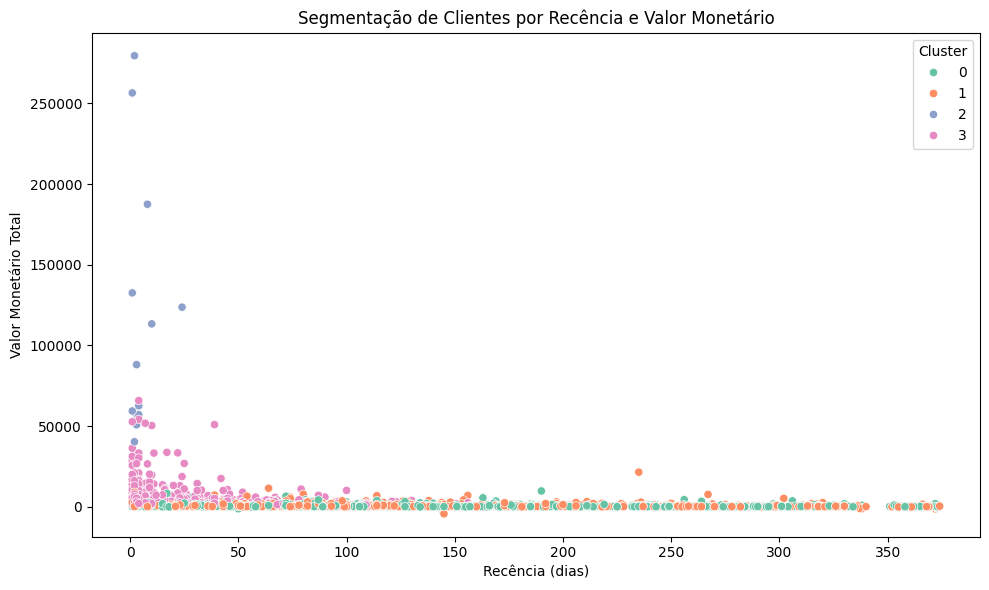

Perfis dos Clusters:
         Recência  Frequência  Valor Monetário  Tempo Médio Entre Compras  \
Cluster                                                                     
0          113.26        2.50           646.07                       2.21   
1          108.97        2.88           834.49                       4.80   
2            4.53       98.40        103319.04                       0.07   
3           19.75       12.73          4679.04                       1.03   

         Variedade de Produtos  Horário Médio de Compra  
Cluster                                                  
0                        35.58                    14.31  
1                        32.13                    11.03  
2                       794.33                    12.56  
3                       155.61                    12.58  

Personas por Cluster:
   Cluster   Persona                                          Descrição  \
0        0  Diversos                  Clientes com comportamento misto

In [29]:
# Instalar bibliotecas (execute uma vez no seu ambiente)
# !pip install openpyxl seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Carregar o dataset
df = pd.read_csv('online_retail.csv', encoding='unicode_escape')

# Pré-processamento
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df.dropna(subset=['CustomerID'])  # Remove clientes sem ID
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Data snapshot para cálculo de Recência
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Cálculo das métricas RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recência',
    'InvoiceNo': 'Frequência',
    'TotalPrice': 'Valor Monetário'
})

# Tempo médio entre compras
tempo_medio = df.groupby('CustomerID')['InvoiceDate'].apply(lambda x: x.sort_values().diff().mean())
rfm['Tempo Médio Entre Compras'] = tempo_medio.dt.days.fillna(0)

# Variedade de produtos
rfm['Variedade de Produtos'] = df.groupby('CustomerID')['StockCode'].nunique()

# Horário médio de compra
df['Hora'] = df['InvoiceDate'].dt.hour
rfm['Horário Médio de Compra'] = df.groupby('CustomerID')['Hora'].mean()

# Substituir valores nulos por zero
rfm.fillna(0, inplace=True)

# Normalização dos dados
scaler = StandardScaler()
rfm_normalizado = scaler.fit_transform(rfm)

# Aplicação do K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_normalizado)

# Visualização dos clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recência', y='Valor Monetário', hue='Cluster', palette='Set2')
plt.title('Segmentação de Clientes por Recência e Valor Monetário')
plt.xlabel('Recência (dias)')
plt.ylabel('Valor Monetário Total')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Exibir os perfis médios de cada cluster
perfil_clusters = rfm.groupby('Cluster').mean().round(2)
print("Perfis dos Clusters:")
print(perfil_clusters)

# Função para gerar personas com base nos clusters
def gerar_personas(rfm):
    perfil_clusters = rfm.groupby('Cluster').mean().round(2)
    personas = []

    for cluster_id, row in perfil_clusters.iterrows():
        recencia = row['Recência']
        frequencia = row['Frequência']
        valor = row['Valor Monetário']
        tempo = row['Tempo Médio Entre Compras']
        variedade = row['Variedade de Produtos']
        horario = row['Horário Médio de Compra']

        if frequencia < 10 and valor < 1000 and variedade > 50:
            nome = "Exploradores"
            descricao = "Clientes novos, exploram muitos produtos, mas compram pouco."
        elif frequencia > 30 and valor > 3000:
            nome = "Leais"
            descricao = "Clientes fiéis, compram com frequência e gastam bastante."
        elif frequencia < 10 and valor > 2000 and variedade < 10:
            nome = "Oportunistas"
            descricao = "Compram apenas em promoções, gastam muito em poucas compras."
        elif frequencia > 20 and valor < 1000 and variedade > 30:
            nome = "Frequentes Econômicos"
            descricao = "Compram com frequência, mas gastam pouco. Gostam de variedade."
        else:
            nome = "Diversos"
            descricao = "Clientes com comportamento misto."

        personas.append({
            'Cluster': cluster_id,
            'Persona': nome,
            'Descrição': descricao,
            'Recência': recencia,
            'Frequência': frequencia,
            'Valor Monetário': valor,
            'Tempo Médio Entre Compras': tempo,
            'Variedade de Produtos': variedade,
            'Horário Médio de Compra': horario
        })

    return pd.DataFrame(personas)

# Função para gerar explicações detalhadas para cada persona
def gerar_explicacoes_personas(rfm_personas):
    explicacoes = []

    for _, row in rfm_personas.iterrows():
        cluster = row['Cluster']
        recencia = row['Recência']
        frequencia = row['Frequência']
        valor = row['Valor Monetário']
        variedade = row['Variedade de Produtos']
        tempo = row['Tempo Médio Entre Compras']

        texto = f"Cluster {cluster} - Persona '{row['Persona']}':\n"
        texto += f"- Recência média: {recencia:.1f} dias desde a última compra.\n"
        texto += f"- Frequência média: {frequencia:.1f} compras.\n"
        texto += f"- Valor médio gasto: R$ {valor:,.2f}.\n"
        texto += f"- Variedade média de produtos comprados: {variedade:.1f}.\n"
        texto += f"- Tempo médio entre compras: {tempo:.2f} dias.\n"

        if recencia > 90:
            texto += "  -> Clientes que não compram há bastante tempo (inativos ou perdidos).\n"
        else:
            texto += "  -> Clientes que compraram recentemente.\n"

        if frequencia > 30:
            texto += "  -> Compram com alta frequência.\n"
        elif frequencia > 10:
            texto += "  -> Compram com frequência moderada.\n"
        else:
            texto += "  -> Compram com pouca frequência.\n"

        if valor > 5000:
            texto += "  -> Gastam muito dinheiro em compras.\n"
        elif valor > 1000:
            texto += "  -> Gastam valor médio nas compras.\n"
        else:
            texto += "  -> Gastam pouco nas compras.\n"

        if variedade > 100:
            texto += "  -> Compram uma grande variedade de produtos.\n"
        elif variedade > 30:
            texto += "  -> Compram uma variedade moderada de produtos.\n"
        else:
            texto += "  -> Compram poucos tipos de produtos.\n"

        texto += "-"*50
        explicacoes.append({'Cluster': cluster, 'Explicação': texto})

    return pd.DataFrame(explicacoes)

# Gerar personas
df_personas = gerar_personas(rfm)
print("\nPersonas por Cluster:")
print(df_personas)

# Gerar explicações detalhadas
df_explicacoes = gerar_explicacoes_personas(df_personas)
print("\nExplicações das Personas:")
for exp in df_explicacoes['Explicação']:
    print(exp, "\n")

# Exportar para Excel se quiser
df_personas.to_excel("personas_clientes.xlsx", index=False)
df_explicacoes.to_excel("explicacoes_personas.xlsx", index=False)
